# Project Name: Banking transaction data analysis and visualization.

Description: Analyzing bank transaction data using following tools:
1. Python (pandas) - for data preprocessing and manipulation
2. Matplotlib/seaborn - for statistical visualizations.
3. SQL - for querying business questions.
4. PowerBI - for interactive dashboard creation.

In [1]:
import pandas as pd
df = pd.read_csv("/content/bank_transactions_data_2.csv")
df.head()


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


Preprocessing and Statistical analysis:

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [3]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [4]:
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.columns

Index(['transactionid', 'accountid', 'transactionamount', 'transactiondate',
       'transactiontype', 'location', 'deviceid', 'ip address', 'merchantid',
       'channel', 'customerage', 'customeroccupation', 'transactionduration',
       'loginattempts', 'accountbalance', 'previoustransactiondate'],
      dtype='object')

# Feature Engineering:

In [8]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['customerage'], q=4, labels = labels)

In [9]:
df[['customerage', 'age_group']].head(10)

,customerage,age_group
0,70,Senior
1,68,Senior
2,19,Young Adult
3,26,Young Adult
4,26,Young Adult
5,18,Young Adult
6,37,Adult
7,67,Senior
8,51,Middle-aged
9,55,Middle-aged


In [10]:
df['high_valuetransaction'] = df['transactionamount'] > 500

In [13]:
df['month'] = df['transactiondate'].dt.month
df['day'] = df['transactiondate'].dt.day_name()
df['hour'] = df['transactiondate'].dt.hour

# Exploratory Data analysis:

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

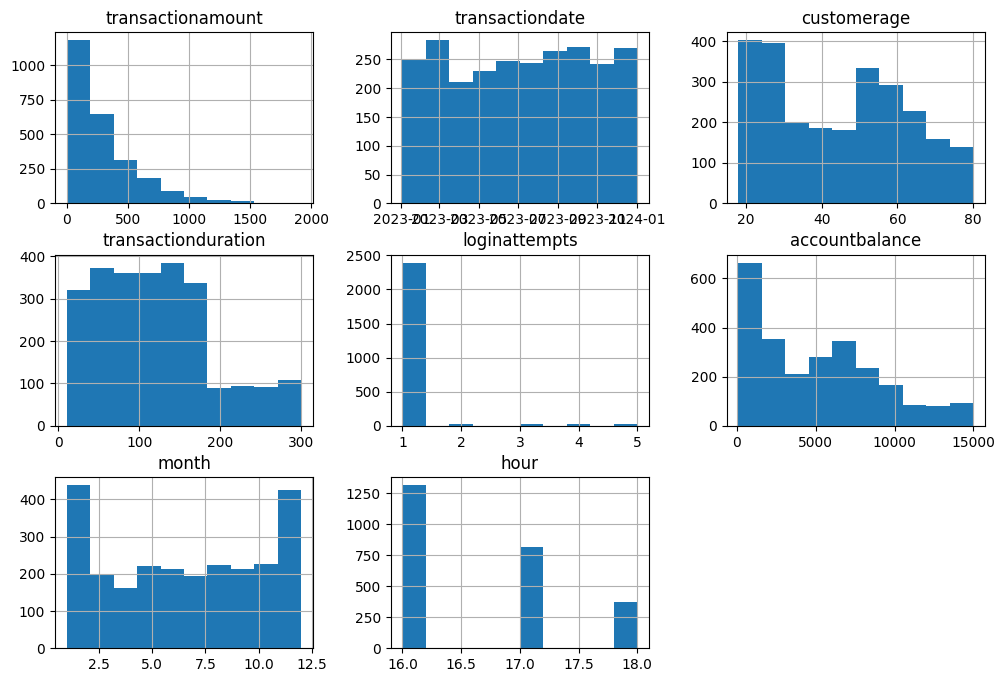

In [15]:
df.hist(figsize=(12,8))
plt.show()

Observations:

Transaction amount:
1. Distribution is right-skewed. Most are small amounts with very few transactions with very high values.
2. Interpretation: Transaction distribution is highly positively skewed, i.e. most transactions are small in value while high-value transactions seems rare.

customerage:
1. Distribution contains both young and senior customers. Ages are spread to multiple ranges.
2. Slightly higher concentration around 20-30 and 50-60 is observed.

transactionduration
1. Most transaction duration are between 30-180 seconds.
2. Fewer transactions take extremely high durations.
3. Interpretation: Long-durations could indicate network delays, authentication delays, etc. Operational efficieny compromised.

loginattempts:
1. Majority at 1. Very few took 2-5 attempts.
2. High login attempts may indicate suspicious activity or forgotten credentials.


accountbalance:
1. Distribution is right-skewed, majority customers maintain lower balances.
2. Majority are regular customers, some fwe are high-value customers holding significantly higher balances.

<Axes: xlabel='transactionamount'>

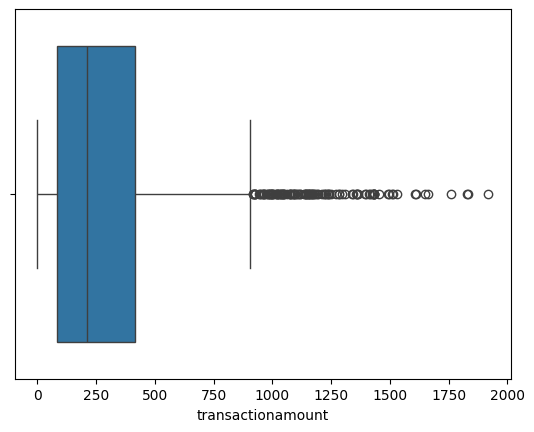

In [16]:
sns.boxplot(x=df['transactionamount'])

Outlier detection:
1. Median -- middle transaction value
2. Box -- where most trasnactions lie
3. whiskers -- normal range
4. Dots outside whiskers -- potential outliers
5. Box shows majority customers transactions, dots beyond upper whisker shows these transactions are high compared to normal customer behaviour.
5. Possible reasons could be premium customers, bulk transfers, abnormal activities, etc.
6. Median line in box is closer to left side, this indicates majority of transactions are smaller amounts.

Final view: These high-value outliers indicates presence of large transactions which is realistic in financial systems, hence they are retained for further analysis rather than removing them

Categorical analysis:

<Axes: xlabel='transactiontype', ylabel='count'>

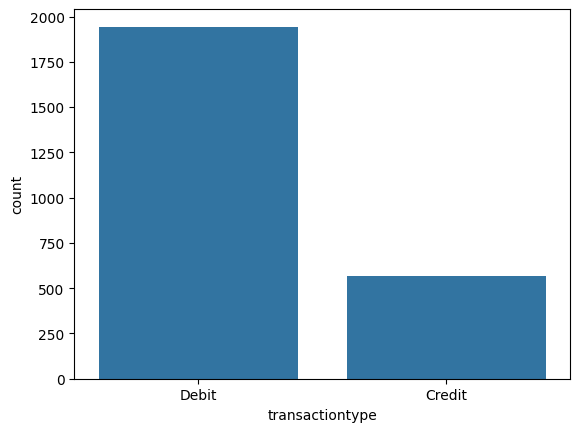

In [17]:
sns.countplot(x='transactiontype', data=df)

Observations:
1. count in countplot means number of transactions.
2. Debit transactions are significantly higher than credit transactions.
3. Debit are around 1900+ and credit are 550-600.
4. strongly indiactes customers perform transactions for spending more rather than incoming credits.
5. Indicates higher outgoing transaction activity and lower incoming transaction frequency.

<Axes: xlabel='channel'>

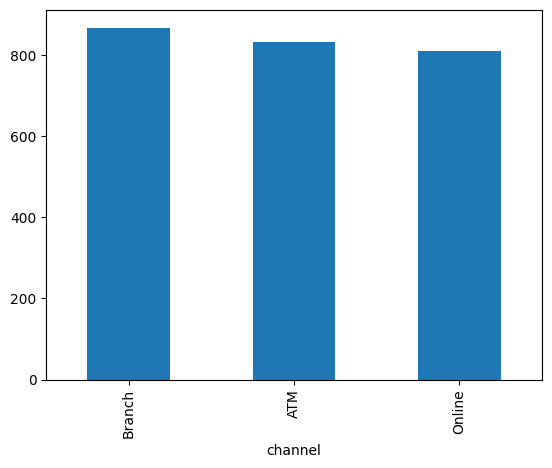

In [18]:
df['channel'].value_counts().plot(kind='bar')

Observations:
1. y-axis shows number of transactions performed though each channel.
2. Bar indiactes transaction counts are relatively balanced across all channels. Approximate pattern observed is Branch has highest count, ATM slightly lower and online has slightly lower than ATM.
3. This majorly indicates customers are actively using all available banking channels.
4. Final interpretation: Branch banking remains slightly more utilized than ATM and online channels, suggesting continued dependence on traditional banking services despite digital adoption.

Bivariate analysis:

<Axes: xlabel='age_group', ylabel='transactionamount'>

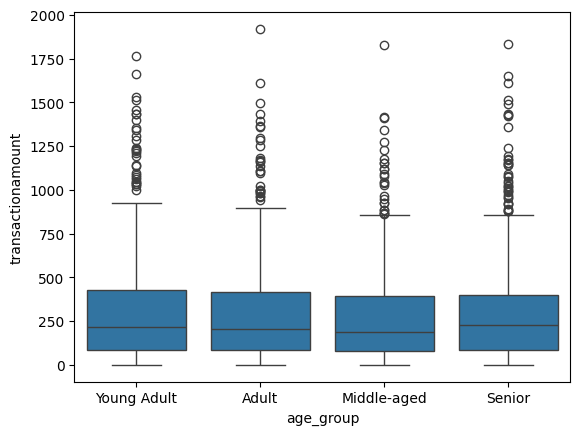

In [19]:
sns.boxplot(x='age_group', y='transactionamount', data=df)

<Axes: xlabel='transactiontype', ylabel='transactionamount'>

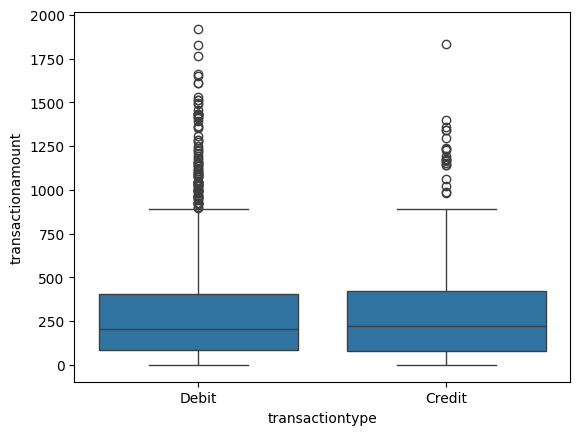

In [20]:
sns.boxplot(x='transactiontype', y='transactionamount', data=df)

<Axes: xlabel='channel', ylabel='transactionamount'>

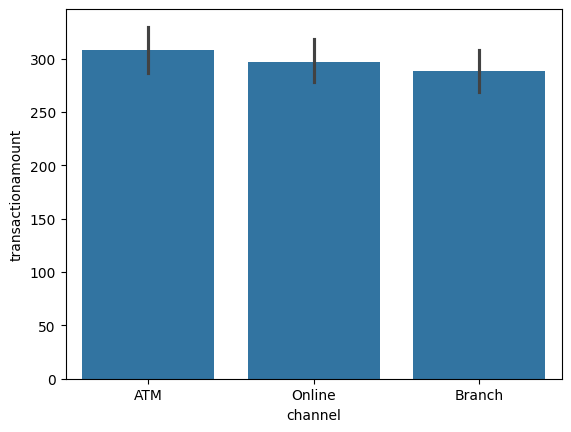

In [21]:
sns.barplot(x='channel', y='transactionamount', data=df)

Observations:
1. Transaction amount among channels are relatively balanced across all channels.
2. No channel seems dominating on a major difference.
3. ATMs are being used slighly more for higher value transactions.

([0, 1, 2, 3],
 [Text(0, 0, 'Doctor'),
  Text(1, 0, 'Student'),
  Text(2, 0, 'Retired'),
  Text(3, 0, 'Engineer')])

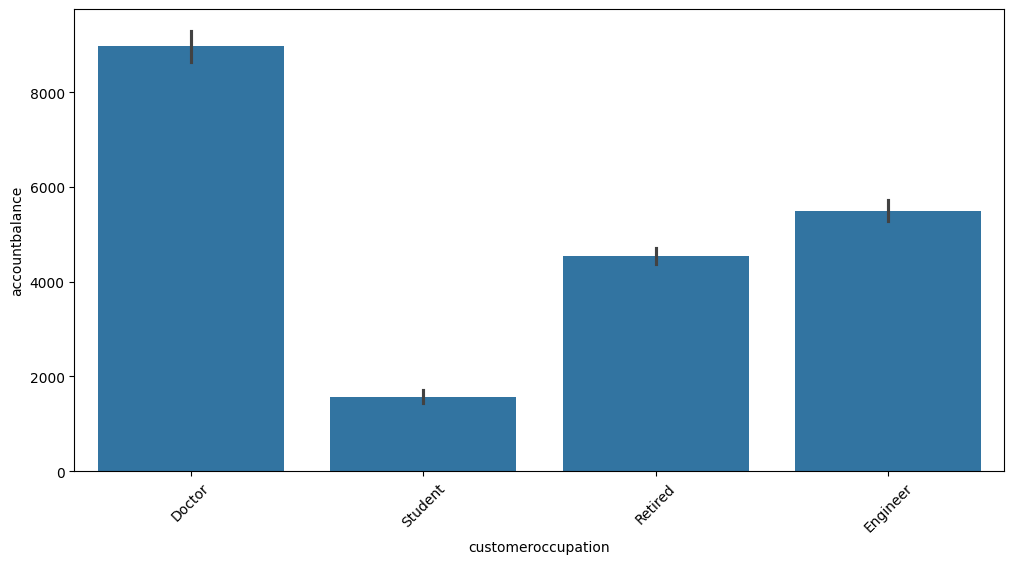

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x='customeroccupation', y='accountbalance', data=df)
plt.xticks(rotation=45)

Observations:
1. Higher account balance holders are majorly doctors, then engineers, then retired customers and atlast students.
2. It indicates higher balance retention is majorly by doctors.

Correlation analysis:

<Axes: >

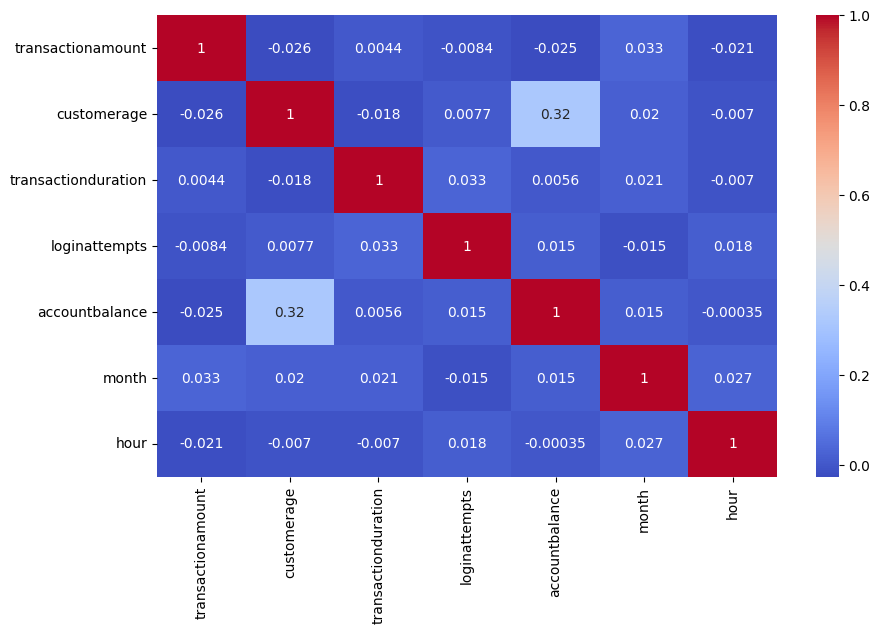

In [23]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

Time based analysis:

<Axes: xlabel='hour', ylabel='count'>

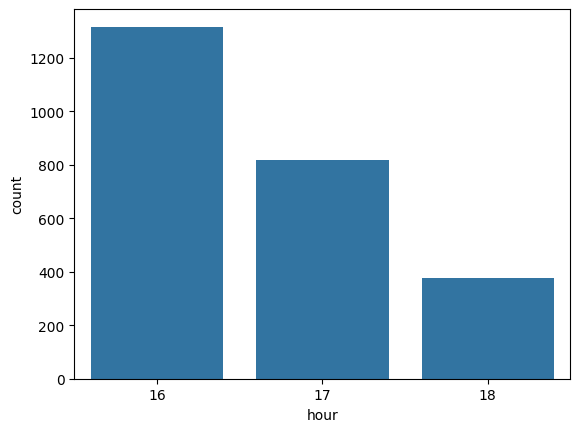

In [25]:
sns.countplot(x='hour', data=df)

<Axes: xlabel='channel', ylabel='high_valuetransaction'>

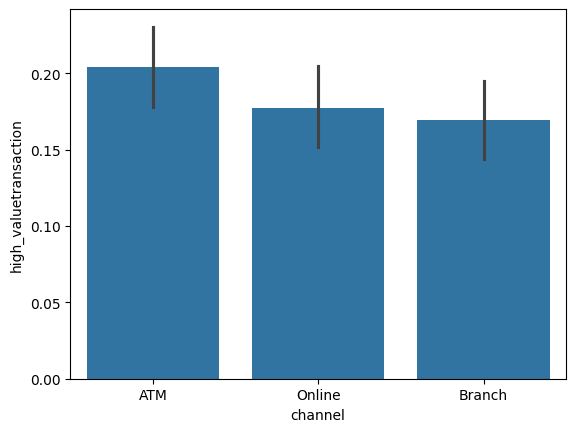

In [26]:
sns.barplot(x='channel', y='high_valuetransaction', data=df)

Exporting for SQL Querying:

In [27]:
df_cleaned = df.copy()

In [28]:
df_cleaned.to_csv('bank_transactions_cleaned.csv', index=False)

In [29]:
from google.colab import files
files.download('bank_transactions_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>